In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Student_Placement_Prediction_10000.csv")

In [9]:
df.head()

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
0,8.02,33,5,4,Yes,58,Placed
1,8.55,99,2,10,No,52,Placed
2,4.66,57,4,9,Yes,85,Placed
3,5.59,99,7,4,No,87,Placed
4,6.03,30,3,7,No,67,Placed


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CGPA                 10000 non-null  float64
 1   AptitudeScore        10000 non-null  int64  
 2   TechnicalSkills      10000 non-null  int64  
 3   CommunicationSkills  10000 non-null  int64  
 4   Internship           10000 non-null  object 
 5   Attendance           10000 non-null  int64  
 6   PlacementStatus      10000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 547.0+ KB


In [11]:
df.describe()

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Attendance
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.234096,65.412600,5.482900,5.508600,74.775700
std,1.593633,20.519212,2.868193,2.891464,14.812398
min,4.500000,30.000000,1.000000,1.000000,50.000000
25%,5.860000,47.000000,3.000000,3.000000,62.000000
50%,7.230000,66.000000,5.000000,6.000000,75.000000
75%,8.620000,83.000000,8.000000,8.000000,88.000000
max,10.000000,100.000000,10.000000,10.000000,100.000000


In [12]:
df.isnull().sum()

,0
CGPA,0
AptitudeScore,0
TechnicalSkills,0
CommunicationSkills,0
Internship,0
Attendance,0
PlacementStatus,0


In [13]:
# Mapping
df["Internship"] = df["Internship"].map({"Yes": 1 , "No": 0})
df['PlacementStatus'] = df['PlacementStatus'].map({"Placed": 1 , "Not Placed": 0})
df

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
0,8.02,33,5,4,1,58,1
1,8.55,99,2,10,0,52,1
2,4.66,57,4,9,1,85,1
3,5.59,99,7,4,0,87,1
4,6.03,30,3,7,0,67,1
...,...,...,...,...,...,...,...
9995,9.26,46,10,10,1,60,1
9996,6.23,32,1,3,1,80,1
9997,7.79,47,6,8,1,71,1
9998,8.84,62,4,3,0,100,1


In [14]:
df

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
0,8.02,33,5,4,1,58,1
1,8.55,99,2,10,0,52,1
2,4.66,57,4,9,1,85,1
3,5.59,99,7,4,0,87,1
4,6.03,30,3,7,0,67,1
...,...,...,...,...,...,...,...
9995,9.26,46,10,10,1,60,1
9996,6.23,32,1,3,1,80,1
9997,7.79,47,6,8,1,71,1
9998,8.84,62,4,3,0,100,1


In [25]:
x = df.drop(columns = ['PlacementStatus'])
y = df['PlacementStatus']
X = df[["CGPA",
        "AptitudeScore",
        "TechnicalSkills",
        "CommunicationSkills",
        "Internship",
        "Attendance"]]

y = df["PlacementStatus"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
from os import X_OK
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)
x_train

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance
8856,6.99,97,10,5,1,92
1545,9.93,39,7,1,1,74
8136,9.92,44,5,4,0,63
7768,8.00,71,4,9,1,91
7782,4.99,45,1,4,1,91
...,...,...,...,...,...,...
1099,5.80,45,9,2,0,98
2514,9.04,91,9,3,0,70
6637,5.99,67,3,2,1,56
2575,5.29,39,5,4,0,69


In [34]:
#logic regression
logic_reg= LogisticRegression()

logic_reg.fit(X_train_scaled, y_train)

logic_pred = logic_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, logic_pred))


Logistic Regression Accuracy: 1.0


In [35]:
knn=KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
knn_pred=knn.predict(X_test_scaled)
print("KNN Accuracy:",accuracy_score(y_test,knn_pred))

KNN Accuracy: 0.999


In [36]:
decision_t = DecisionTreeClassifier(random_state=42)
decision_t.fit(X_train,y_train)
decision_t_pred=decision_t.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(y_test,decision_t_pred))

Decision Tree Accuracy: 0.9965


In [37]:
random_f=RandomForestClassifier(random_state=42)
random_f.fit(X_train,y_train)
random_f_pred=random_f.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,random_f_pred))

Random Forest Accuracy: 0.9995


In [39]:
conclusion=pd.DataFrame({
    "Model":[
        "logistic regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,logic_pred),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,decision_t_pred),
        accuracy_score(y_test,random_f_pred)
    ]
})

In [40]:
conclusion

,Model,Accuracy
0,logistic regression,1.0000
1,KNN,0.9990
2,Decision Tree,0.9965
3,Random Forest,0.9995


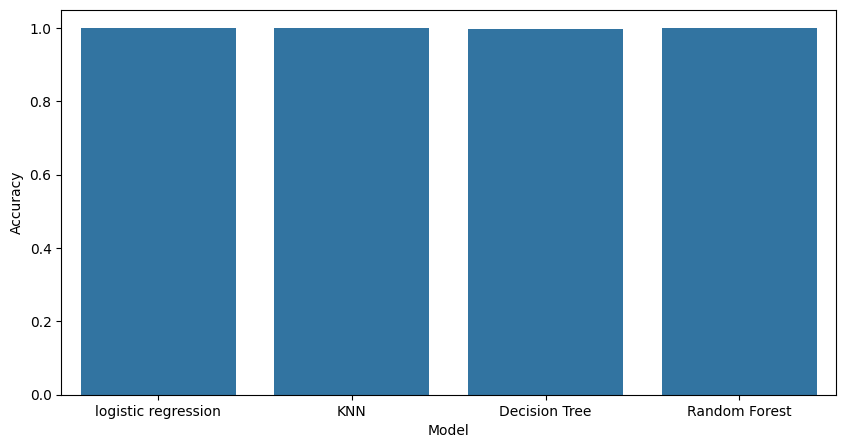

In [61]:
plt.figure(figsize=(10,5))
sns.barplot(x="Model",y="Accuracy",data=conclusion)
plt.show()

Loan Approval Prediction

In [42]:
df1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LoanApprovalPrediction.csv")

In [43]:
df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [45]:
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [47]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [48]:
df1.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [49]:
df1.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


In [106]:
if 'Loan_ID' in df1.columns:
    df1.drop(['Loan_ID'],inplace=True)
df1

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,1
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0,1
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0,1
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2,1
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [68]:
df1['Gender'].fillna(df1['Gender'].mode()[0], inplace=True)
df1['Married'].fillna(df1['Married'].mode()[0], inplace=True)
df1['Dependents'].fillna(df1['Dependents'].mode()[0], inplace=True)
df1['Self_Employed'].fillna(df1['Self_Employed'].mode()[0], inplace=True)
df1['Credit_History'].fillna(df1['Credit_History'].mode()[0], inplace=True)

# Fill numerical missing values

df1['LoanAmount'].fillna(df1['LoanAmount'].median(), inplace=True)
df1['Loan_Amount_Term'].fillna(df1['Loan_Amount_Term'].median(), inplace=True)

/tmp/ipykernel_3246/2169317674.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Gender'].fillna(df1['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_3246/2169317674.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [72]:
LE = LabelEncoder()

for column in df1.columns:
    if df1[column].dtype == 'object':
        df1[column] = LE.fit_transform(df1[column])

In [73]:
df1

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,1
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0,1
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0,1
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2,1
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [75]:
X = df1.drop("Loan_Status", axis=1)
y = df1["Loan_Status"]

In [76]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [77]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

In [78]:
Legistic_reg=LogisticRegression()
Legistic_reg.fit(X_train,y_train)
logistic_pred=Legistic_reg.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,logistic_pred))

Logistic Regression Accuracy: 0.8166666666666667


In [94]:
k_nn = KNeighborsClassifier(n_neighbors=5)

k_nn.fit(X_train, y_train)

knn_pred = k_nn.predict(X_test)

print(" Accuracy of KNN:")
print(accuracy_score(y_test,knn_pred))

 Accuracy of KNN:
0.775


In [98]:
d_tree = DecisionTreeClassifier(random_state=42)

d_tree.fit(X_train, y_train)

d_tree_pred = d_tree.predict(X_test)

print(" Accuracy of Decision Tree:")
print(accuracy_score(y_test, d_tree_pred))

 Accuracy of Decision Tree:
0.7


In [99]:
random_f = RandomForestClassifier(random_state=42)

random_f.fit(X_train, y_train)

random_pred = random_f.predict(X_test)

print(" Accuracy of Random Tree:")
print(accuracy_score(y_test,random_pred))

 Accuracy of Random Tree:
0.8083333333333333


In [100]:
accuracy = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,logistic_pred),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,d_tree_pred),
        accuracy_score(y_test,random_pred)
    ]
})

print(accuracy)

                 Model  Accuracy
0  Logistic Regression  0.816667
1                  KNN  0.775000
2        Decision Tree  0.700000
3        Random Forest  0.808333


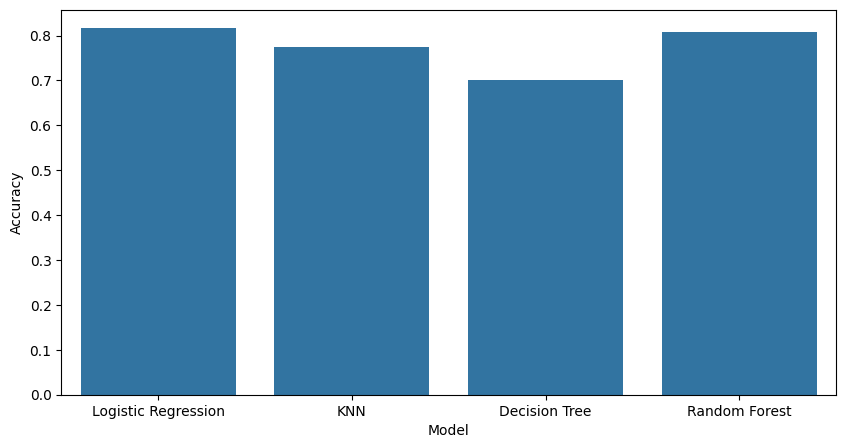

In [101]:
plt.figure(figsize=(10,5))
sns.barplot(x="Model",y="Accuracy",data=accuracy)
plt.show()